<a href="https://colab.research.google.com/github/annshita/CT-Scan-based-Kidney-Disease-Diagnosis/blob/main/SAM_Segmentation_1500_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import random
import torch
import numpy as np

from tqdm import tqdm
from collections import defaultdict

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

INPUT_DIR = "/content/drive/MyDrive/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
OUTPUT_DIR = "/content/drive/MyDrive/SAM_Masked_1500"

os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(42)

image_extensions = (".jpg", ".jpeg", ".png")

classwise_images = defaultdict(list)

for class_name in os.listdir(INPUT_DIR):

    class_path = os.path.join(INPUT_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_extensions):

                full_path = os.path.join(root, file)

                classwise_images[class_name].append(full_path)

print("\nOriginal Dataset Distribution:\n")

total_images = 0

for cls, imgs in classwise_images.items():

    print(f"{cls}: {len(imgs)}")

    total_images += len(imgs)

print(f"\nTotal Images: {total_images}")

TARGET_TOTAL = 1500

selected_images = []

for cls, imgs in classwise_images.items():

    class_ratio = len(imgs) / total_images

    n_samples = int(class_ratio * TARGET_TOTAL)

    sampled = random.sample(
        imgs,
        min(n_samples, len(imgs))
    )

    selected_images.extend(sampled)

print(f"\nSelected Images: {len(selected_images)}")


CHECKPOINT_PATH = "/content/sam_vit_b.pth"

if not os.path.exists(CHECKPOINT_PATH):

    !wget -O /content/sam_vit_b.pth \
    https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("\nUsing device:", DEVICE)

sam = sam_model_registry["vit_b"](
    checkpoint=CHECKPOINT_PATH
)

sam.to(device=DEVICE)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=8,       # faster
    pred_iou_thresh=0.86,
    stability_score_thresh=0.90,
    crop_n_layers=0,
    min_mask_region_area=100
)


for idx, img_path in enumerate(
    tqdm(
        selected_images,
        desc="Generating SAM Masks",
        unit="image"
    )
):

    try:


        image = cv2.imread(img_path)

        if image is None:
            continue

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )



        masks = mask_generator.generate(image_rgb)


        combined_mask = np.zeros(
            image_rgb.shape[:2],
            dtype=np.uint8
        )

        for mask_data in masks:

            segmentation = mask_data["segmentation"]

            combined_mask = np.logical_or(
                combined_mask,
                segmentation
            )

        combined_mask = combined_mask.astype(np.uint8)



        mask_3ch = np.stack(
            [combined_mask]*3,
            axis=-1
        )

        masked_image = image_rgb * mask_3ch



        relative_path = os.path.relpath(
            img_path,
            INPUT_DIR
        )

        save_path = os.path.join(
            OUTPUT_DIR,
            relative_path
        )

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        masked_bgr = cv2.cvtColor(
            masked_image.astype(np.uint8),
            cv2.COLOR_RGB2BGR
        )

        cv2.imwrite(save_path, masked_bgr)



        if (idx + 1) % 100 == 0:

            print(f"\nProcessed {idx+1} images")

    except Exception as e:

        print(f"\nError processing {img_path}")
        print(e)

print("\nDone! Stratified masked dataset saved.")

  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Original Dataset Distribution:

Normal: 5077
Tumor: 2283
Stone: 1377
Cyst: 3709

Total Images: 12446

Selected Images: 1498

Using device: cuda


Generating SAM Masks:   7%|▋         | 100/1498 [03:47<21:20,  1.09image/s]


Processed 100 images


Generating SAM Masks:  13%|█▎        | 200/1498 [05:14<19:03,  1.14image/s]


Processed 200 images


...


Processed 1300 images


Generating SAM Masks:  93%|█████████▎| 1400/1498 [31:06<02:36,  1.59s/image]


Processed 1400 images


Generating SAM Masks: 100%|██████████| 1498/1498 [33:25<00:00,  1.34s/image]


Done! Stratified masked dataset saved.



Masked Image Count Per Class:

Normal: 611
Tumor: 275
Stone: 165
Cyst: 447

Total Masked Images: 1498


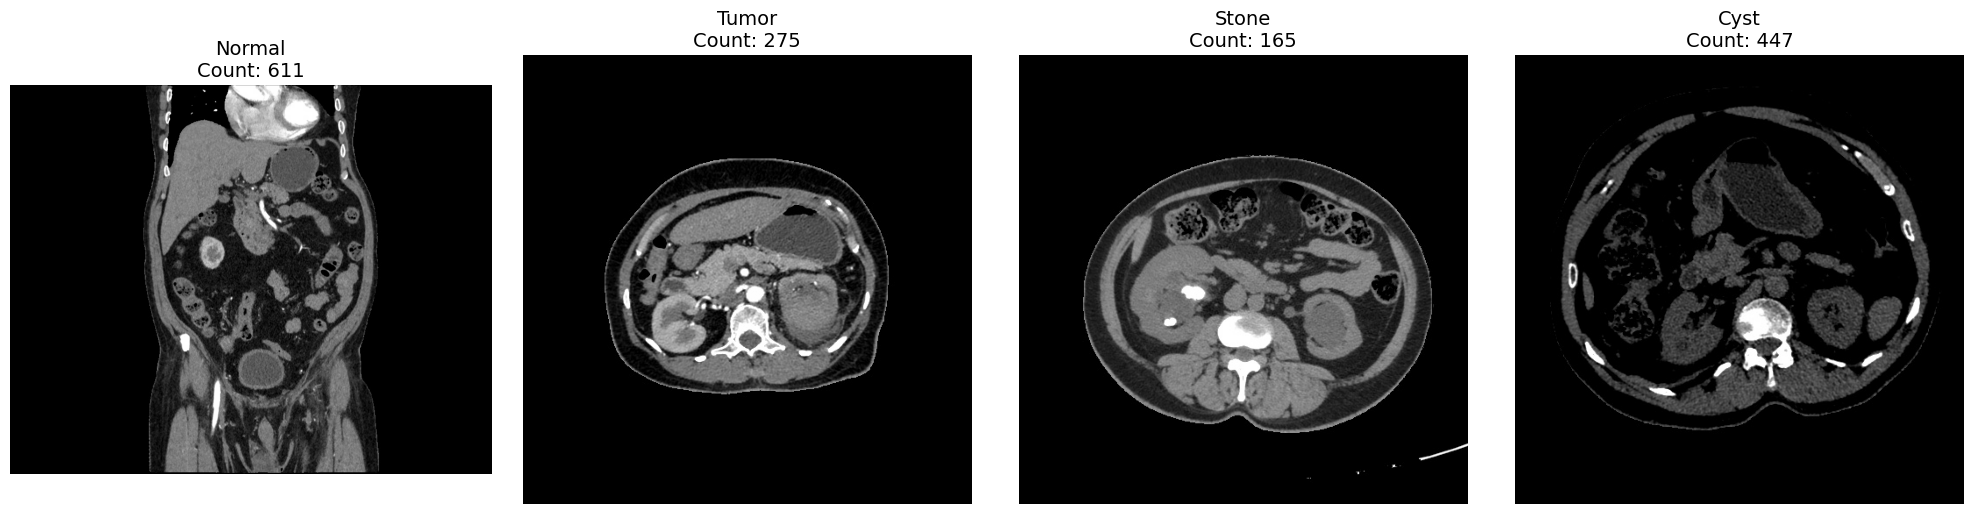

In [ ]:

import os
import cv2
import random
import matplotlib.pyplot as plt
from collections import defaultdict



MASKED_DIR = "/content/drive/MyDrive/SAM_Masked_1500"



image_extensions = (".jpg", ".jpeg", ".png")

classwise_masked = defaultdict(list)

for class_name in os.listdir(MASKED_DIR):

    class_path = os.path.join(MASKED_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_extensions):

                full_path = os.path.join(root, file)

                classwise_masked[class_name].append(full_path)


print("\nMasked Image Count Per Class:\n")

total = 0

for cls, imgs in classwise_masked.items():

    print(f"{cls}: {len(imgs)}")

    total += len(imgs)

print(f"\nTotal Masked Images: {total}")



num_classes = len(classwise_masked)

plt.figure(figsize=(5 * num_classes, 5))

for idx, (cls, imgs) in enumerate(classwise_masked.items()):

    # Random image
    sample_img_path = random.choice(imgs)

    # Read image
    image = cv2.imread(sample_img_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot
    plt.subplot(1, num_classes, idx + 1)

    plt.imshow(image)

    plt.title(f"{cls}\nCount: {len(imgs)}", fontsize=14)

    plt.axis("off")

plt.tight_layout()

plt.show()